In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

from pathlib import Path
from sklearn.model_selection import train_test_split

In [14]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [15]:
df = efnetdf.copy()

In [16]:
modele = "EfficientNet-B4"

# Separation Train Test


In [17]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [18]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

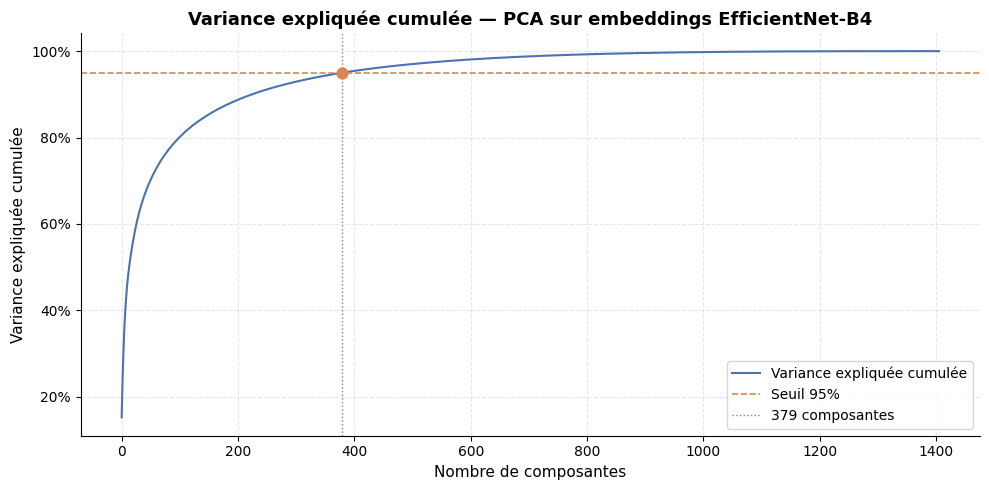

379 dimensions à garder pour conserver 95% de la variance


In [19]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [20]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape


(1406, 379)

# Clustering

In [21]:
k_means= KMeans(n_clusters=2, random_state=42)

In [22]:
k_means.fit(X_pca)
cluster_labels = k_means.labels_

In [23]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

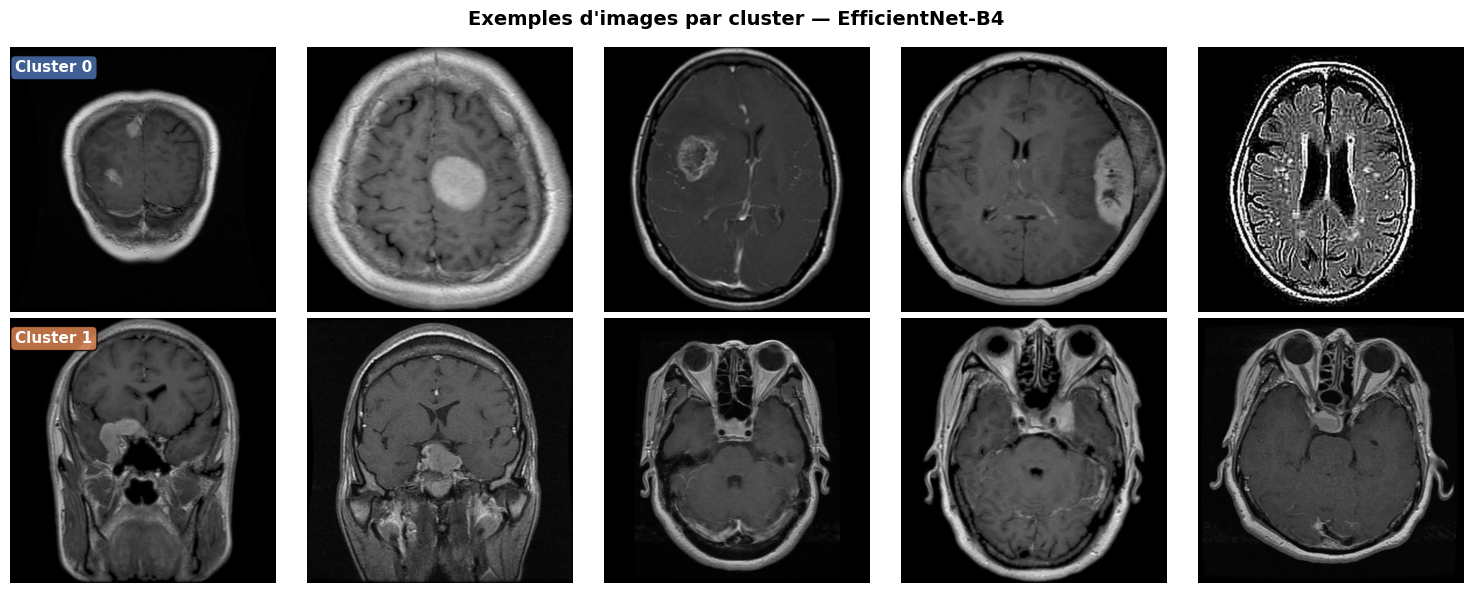

In [24]:
from PIL import Image

CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}
n_samples = 5
clusters = [0, 1]
fig, axes = plt.subplots(len(clusters), n_samples, figsize=(15, 6))
fig.suptitle(f"Exemples d'images par cluster — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters):
    sample_paths = (
        train_df[train_df["cluster"] == cluster_id]["image_path"]
        .sample(n_samples, random_state=42)
        .tolist()
    )
    for col_idx, path in enumerate(sample_paths):
        ax = axes[row_idx][col_idx]
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id}",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

In [25]:
k_means_labels = k_means.predict(X_pca)
print("silhouette_score: ", silhouette_score(X_pca,cluster_labels))

silhouette_score:  0.11739034380268744


# Visualisation

In [26]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

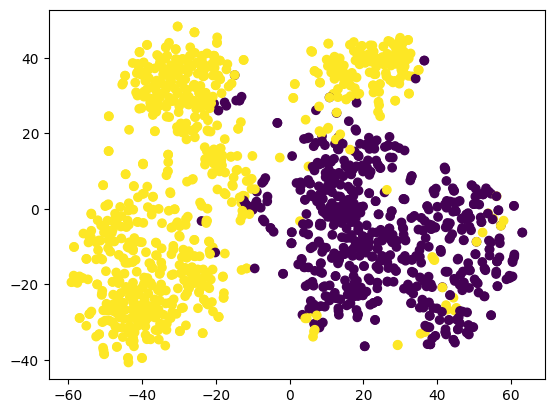

In [27]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

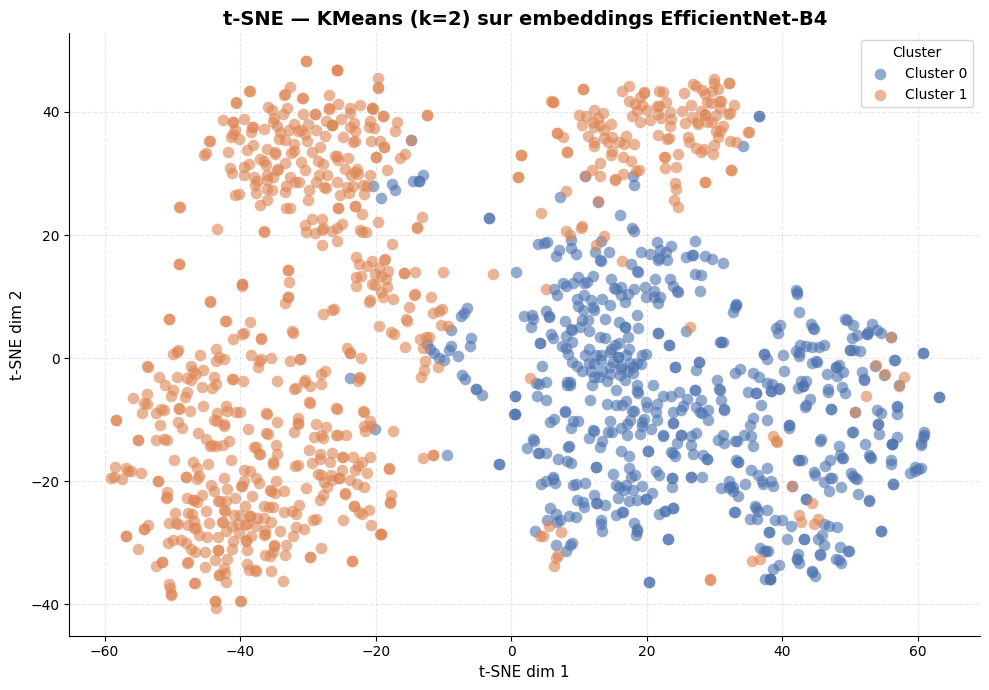

In [28]:
CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — KMeans (k=2) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# SCORES

Mapping retenu : cluster 0 → normal, cluster 1 → cancer

  Accuracy   : 0.7900
  Precision  : 0.8372  (cancer=positif)
  Recall     : 0.7200  (cancer=positif)
  F1-score   : 0.7742
  F2-score   : 0.7407  (recall x2)
  ARI        : 0.3298

              precision    recall  f1-score   support

      Normal       0.75      0.86      0.80        50
      Cancer       0.84      0.72      0.77        50

    accuracy                           0.79       100
   macro avg       0.80      0.79      0.79       100
weighted avg       0.80      0.79      0.79       100

Confiance par cluster (pureté sur le jeu de test) :
  Cluster 0 (normal) : 14 cancer / 43 normal → 75% de normal
  Cluster 1 (cancer) : 36 cancer / 7 normal → 84% de cancer


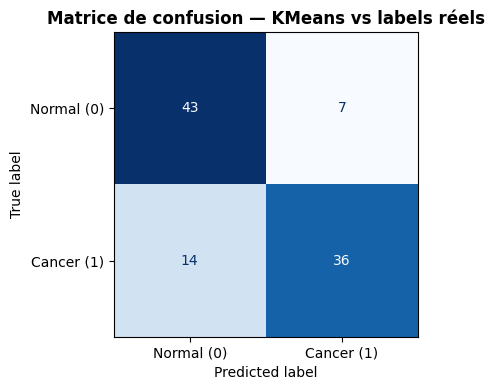

In [29]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)

X_test = test_df.drop(columns=["label", "image_path"])
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_test_pca = pcamodel.transform(X_test_scaled)
cluster_pred = k_means.predict(X_test_pca)
y_true = test_df["label"].values  # 0=normal, 1=cancer

# Align cluster labels: try direct and inverted, keep best accuracy
acc_direct   = (cluster_pred == y_true).mean()
acc_inverted = (1 - cluster_pred == y_true).mean()

if acc_direct >= acc_inverted:
    aligned_pred = cluster_pred
    cluster_to_class = {0: "normal", 1: "cancer"}
else:
    aligned_pred = 1 - cluster_pred
    cluster_to_class = {0: "cancer", 1: "normal"}

ari = adjusted_rand_score(y_true, aligned_pred)
print(f"Mapping retenu : cluster 0 → {cluster_to_class[0]}, cluster 1 → {cluster_to_class[1]}\n")

# ── Métriques ──────────────────────────────────────────────────────────────
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(y_true, aligned_pred):.4f}")
print(f"  Precision  : {precision_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  Recall     : {recall_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  F1-score   : {f1_score(y_true, aligned_pred):.4f}")
print(f"  F2-score   : {fbeta_score(y_true, aligned_pred, beta=2):.4f}  (recall x2)")
print(f"  ARI        : {ari:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, aligned_pred, target_names=["Normal", "Cancer"]))

# ── Confiance par cluster ──────────────────────────────────────────────────
print("Confiance par cluster (pureté sur le jeu de test) :")
for c in [0, 1]:
    mask = aligned_pred == c
    n = mask.sum()
    if n == 0:
        continue
    n_cancer = (y_true[mask] == 1).sum()
    n_normal = (y_true[mask] == 0).sum()
    dominant = "cancer" if n_cancer >= n_normal else "normal"
    confidence = max(n_cancer, n_normal) / n
    print(f"  Cluster {c} ({cluster_to_class[c]:>6}) : {n_cancer} cancer / {n_normal} normal "
          f"→ {confidence:.0%} de {dominant}")

# ── Matrice de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, aligned_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Cancer (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matrice de confusion — KMeans vs labels réels", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()